# 🎯 MSME Credit Scoring Model — Alternative Credit Engine

## Objective
Build a **multi-class classification model** to predict credit labels (Approve / Review / Reject) using alternative data sources:
- GST compliance patterns
- UPI transaction consistency
- Bank statement analysis
- Business age & industry trends

---

## What We'll Build:
1. Feature Engineering (4 new features)
2. Data Preprocessing Pipeline
3. Model 1: Logistic Regression (Baseline)
4. Model 2: Random Forest (Main Model)
5. Model Evaluation & Comparison
6. Credit Score Generation (300-900 scale)
7. Feature Importance Analysis
8. Model Deployment (.pkl files)

In [4]:
# INTERVIEW NOTE: Professional imports with clear organization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
import joblib

# Settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
%matplotlib inline

print("✅ Libraries loaded successfully!")
print(f"📅 Model Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✅ Libraries loaded successfully!
📅 Model Training Date: 2026-04-01 23:57


---
## 1️⃣ Load Cleaned Data

In [5]:
# Load from processed folder (output of EDA)
df = pd.read_csv('../data/processed/msme_cleaned.csv')

print(f"📊 Dataset Shape: {df.shape}")
print(f"🎯 Target Distribution:\n{df['credit_label'].value_counts()}")

df.head()

📊 Dataset Shape: (5000, 26)
🎯 Target Distribution:
credit_label
Approve    2437
Review     2309
Reject      254
Name: count, dtype: int64


,msme_id,business_name,industry_type,business_age_years,state,udyam_registered,gst_filing_months,avg_monthly_turnover,gst_compliance_score,turnover_growth_rate,avg_monthly_upi_inflow,upi_transaction_consistency,num_unique_buyers,peak_to_offpeak_ratio,loan_amount_requested,loan_purpose,existing_loans,collateral_available,credit_score,credit_label,filed_months,total_months,gst_filing_pct,avg_monthly_balance_lakhs,total_bounces,low_balance_days_pct
0,MSME000001,Patel Choudhury Services,Retail,4,Kerala,0,12,556269.33,74.97,27.70,171972.11,0.671,472,4.59,4373893.12,Working Capital,0,1,65.63,Review,12,12,100.00,0.83,10,10.0
1,MSME000002,Patel Bakshi Corporation,Textile,17,Haryana,0,12,2389912.87,80.45,15.44,1814196.53,0.330,89,3.89,21898418.46,Expansion,0,0,55.00,Review,12,12,100.00,3.58,5,7.8
2,MSME000003,"Maharaj, Konda and Kapoor",Services,5,Madhya Pradesh,1,9,4971826.50,60.58,61.71,3266959.95,0.658,21,1.81,19337374.77,Expansion,0,1,67.04,Review,9,12,75.00,7.46,10,15.8
3,MSME000004,Chaudry Ltd,Food & Beverage,3,Telangana,0,6,21144.39,43.03,55.27,15702.77,0.456,242,3.36,152725.99,Working Capital,0,1,32.29,Reject,6,12,50.00,0.03,5,22.8
4,MSME000005,"Chahal, Sami and Balay",Manufacturing,4,Punjab,1,11,2585193.12,54.15,49.35,2015932.30,0.864,95,2.03,35926099.56,Machinery,0,0,65.27,Review,11,12,91.67,3.88,5,18.3


---
## 2️⃣ Feature Engineering

**INTERVIEW NOTE:** "Sir, I created 4 domain-specific features based on business logic:
1. **turnover_per_year** — Normalized growth metric
2. **upi_to_turnover_ratio** — Digital payment adoption rate
3. **compliance_consistency_score** — Combined reliability index
4. **loan_to_turnover_ratio** — Leverage assessment"

In [6]:
# Feature Engineering
print("🔧 Creating Engineered Features...\n")

# 1. Turnover per year of business existence
df['turnover_per_year'] = df['avg_monthly_turnover'] * 12 / (df['business_age_years'] + 1)

# 2. UPI to Turnover Ratio (digital payment adoption)
df['upi_to_turnover_ratio'] = df['avg_monthly_upi_inflow'] / (df['avg_monthly_turnover'] + 1)

# 3. Compliance-Consistency Score
df['compliance_consistency_score'] = (df['gst_compliance_score'] * df['upi_transaction_consistency']) / 100

# 4. Loan to Turnover Ratio (leverage)
df['loan_to_turnover_ratio'] = df['loan_amount_requested'] / ((df['avg_monthly_turnover'] * 12) + 1)

print("✅ 4 new features created!")
print("\n📊 New Features Preview:")
print(df[['turnover_per_year', 'upi_to_turnover_ratio', 
         'compliance_consistency_score', 'loan_to_turnover_ratio']].describe())

🔧 Creating Engineered Features...

✅ 4 new features created!

📊 New Features Preview:
       turnover_per_year  upi_to_turnover_ratio  compliance_consistency_score  \
count       5.000000e+03            5000.000000                   5000.000000   
mean        1.671629e+06               0.550425                      0.583025   
std         4.731312e+06               0.142971                      0.174432   
min         8.058547e+03               0.300157                      0.057443   
25%         2.475814e+05               0.427263                      0.454918   
50%         6.348005e+05               0.549830                      0.585772   
75%         1.598295e+06               0.672877                      0.715500   
max         1.797608e+08               0.799903                      0.999400   

       loan_to_turnover_ratio  
count             5000.000000  
mean                 0.560634  
std                  0.250141  
min                  0.166841  
25%                  0.3

---
## 3️⃣ Feature Selection & Preprocessing

In [7]:
# INTERVIEW NOTE: Selecting features based on EDA insights
# Removed low-importance and redundant features

feature_columns = [
    # Original Features
    'business_age_years',
    'gst_filing_months',
    'gst_compliance_score',
    'avg_monthly_turnover',
    'turnover_growth_rate',
    'avg_monthly_upi_inflow',
    'upi_transaction_consistency',
    'num_unique_buyers',
    'peak_to_offpeak_ratio',
    'loan_amount_requested',
    'credit_score',
    'total_bounces',
    'low_balance_days_pct',
    'gst_filing_pct',
    
    # Engineered Features
    'turnover_per_year',
    'upi_to_turnover_ratio',
    'compliance_consistency_score',
    'loan_to_turnover_ratio',
    
    # Categorical (will encode)
    'industry_type',
    'state',
    'loan_purpose',
    'udyam_registered',
    'existing_loans',
    'collateral_available'
]

target_column = 'credit_label'

print(f"📋 Selected Features: {len(feature_columns)}")
print(f"🎯 Target Variable: {target_column}")

📋 Selected Features: 24
🎯 Target Variable: credit_label


In [8]:
# Separate features and target
X = df[feature_columns].copy()
y = df[target_column].copy()

print(f"\n✅ X shape: {X.shape}")
print(f"✅ y shape: {y.shape}")

# Check for missing values
print(f"\n❓ Missing values in X:\n{X.isnull().sum().sum()} total")
print(f"❓ Missing values in y: {y.isnull().sum()}")

# Fill any missing values if present
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(X.mode().iloc[0])  # For categorical


✅ X shape: (5000, 24)
✅ y shape: (5000,)

❓ Missing values in X:
0 total
❓ Missing values in y: 0


In [9]:
# INTERVIEW NOTE: Encoding categorical variables
# LabelEncoder for tree-based models (Random Forest handles ordinal well)

categorical_cols = ['industry_type', 'state', 'loan_purpose']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print("✅ Categorical features encoded")

# Binary features already 0/1
print(f"\n📊 Final X shape: {X.shape}")
X.head()

✅ Categorical features encoded

📊 Final X shape: (5000, 24)


,business_age_years,gst_filing_months,gst_compliance_score,avg_monthly_turnover,turnover_growth_rate,avg_monthly_upi_inflow,upi_transaction_consistency,num_unique_buyers,peak_to_offpeak_ratio,loan_amount_requested,credit_score,total_bounces,low_balance_days_pct,gst_filing_pct,turnover_per_year,upi_to_turnover_ratio,compliance_consistency_score,loan_to_turnover_ratio,industry_type,state,loan_purpose,udyam_registered,existing_loans,collateral_available
0,4,12,74.97,556269.33,27.70,171972.11,0.671,472,4.59,4373893.12,65.63,10,10.0,100.00,1.335046e+06,0.309152,0.503049,0.655242,2,6,3,0,0,1
1,17,12,80.45,2389912.87,15.44,1814196.53,0.330,89,3.89,21898418.46,55.00,5,7.8,100.00,1.593275e+06,0.759105,0.265485,0.763571,4,4,0,0,0,0
2,5,9,60.58,4971826.50,61.71,3266959.95,0.658,21,1.81,19337374.77,67.04,10,15.8,75.00,9.943653e+06,0.657094,0.398616,0.324116,3,7,0,1,0,1
3,3,6,43.03,21144.39,55.27,15702.77,0.456,242,3.36,152725.99,32.29,5,22.8,50.00,6.343317e+04,0.742610,0.196217,0.601915,0,12,3,0,0,1
4,4,11,54.15,2585193.12,49.35,2015932.30,0.864,95,2.03,35926099.56,65.27,5,18.3,91.67,6.204463e+06,0.779799,0.467856,1.158073,1,9,2,1,0,0


---
## 4️⃣ Train-Test Split

**INTERVIEW NOTE:** "Sir, I used stratified split to maintain class distribution in both train and test sets. This is critical for imbalanced datasets."

In [10]:
# Stratified split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("📊 Train-Test Split Complete!")
print(f"\n   Train Set: {X_train.shape[0]:,} samples")
print(f"   Test Set:  {X_test.shape[0]:,} samples")

print(f"\n🎯 Train Target Distribution:")
print(y_train.value_counts())

print(f"\n🎯 Test Target Distribution:")
print(y_test.value_counts())

📊 Train-Test Split Complete!

   Train Set: 4,000 samples
   Test Set:  1,000 samples

🎯 Train Target Distribution:
credit_label
Approve    1950
Review     1847
Reject      203
Name: count, dtype: int64

🎯 Test Target Distribution:
credit_label
Approve    487
Review     462
Reject      51
Name: count, dtype: int64


In [11]:
# Feature Scaling (important for Logistic Regression)
# INTERVIEW NOTE: Random Forest doesn't need scaling, but LR does

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling complete (StandardScaler)")

✅ Feature scaling complete (StandardScaler)


---
## 5️⃣ Model 1: Logistic Regression (Baseline)

**Why Logistic Regression?**
- Fast, interpretable baseline
- Works well with scaled features
- Provides probability outputs

In [12]:
print("🚀 Training Logistic Regression...\n")

# Initialize model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # Handle class imbalance
)

# Train
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)

# Evaluation
print("=" * 60)
print("📊 LOGISTIC REGRESSION - RESULTS")
print("=" * 60)

print(f"\n✅ Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_lr))

print("\n🎯 Confusion Matrix:")
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

🚀 Training Logistic Regression...

📊 LOGISTIC REGRESSION - RESULTS

✅ Accuracy: 0.9750

📋 Classification Report:
              precision    recall  f1-score   support

     Approve       0.99      0.99      0.99       487
      Reject       0.79      0.98      0.88        51
      Review       0.99      0.96      0.97       462

    accuracy                           0.97      1000
   macro avg       0.92      0.98      0.95      1000
weighted avg       0.98      0.97      0.98      1000


🎯 Confusion Matrix:
[[482   0   5]
 [  0  50   1]
 [  6  13 443]]


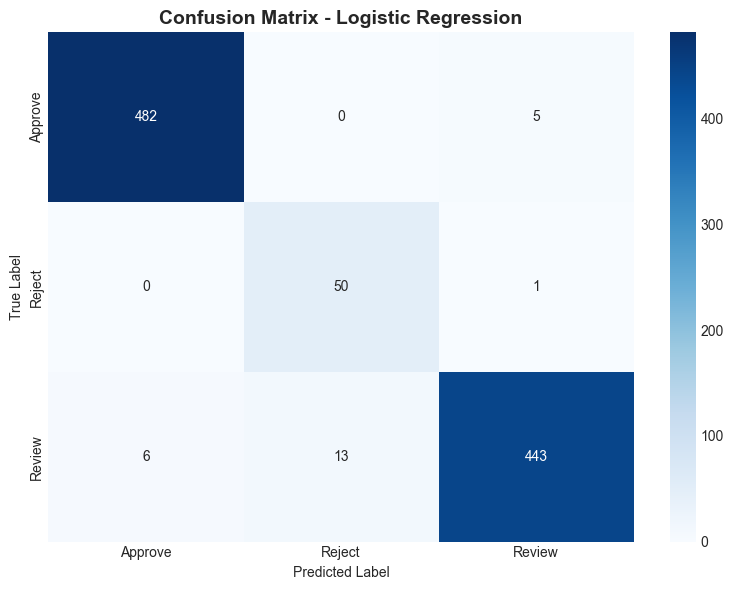

In [13]:
# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=lr_model.classes_, 
            yticklabels=lr_model.classes_)
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

---
## 6️⃣ Model 2: Random Forest (Main Model)

**Why Random Forest?**
- Handles non-linear relationships
- Provides feature importance
- Robust to outliers
- No scaling needed

In [14]:
print("🌲 Training Random Forest Classifier...\n")

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Train (using unscaled data — RF doesn't need scaling)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

# Evaluation
print("=" * 60)
print("🌲 RANDOM FOREST - RESULTS")
print("=" * 60)

print(f"\n✅ Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n🎯 Confusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

🌲 Training Random Forest Classifier...

🌲 RANDOM FOREST - RESULTS

✅ Accuracy: 0.9980

📋 Classification Report:
              precision    recall  f1-score   support

     Approve       1.00      1.00      1.00       487
      Reject       1.00      0.96      0.98        51
      Review       1.00      1.00      1.00       462

    accuracy                           1.00      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      1.00      1.00      1000


🎯 Confusion Matrix:
[[487   0   0]
 [  0  49   2]
 [  0   0 462]]


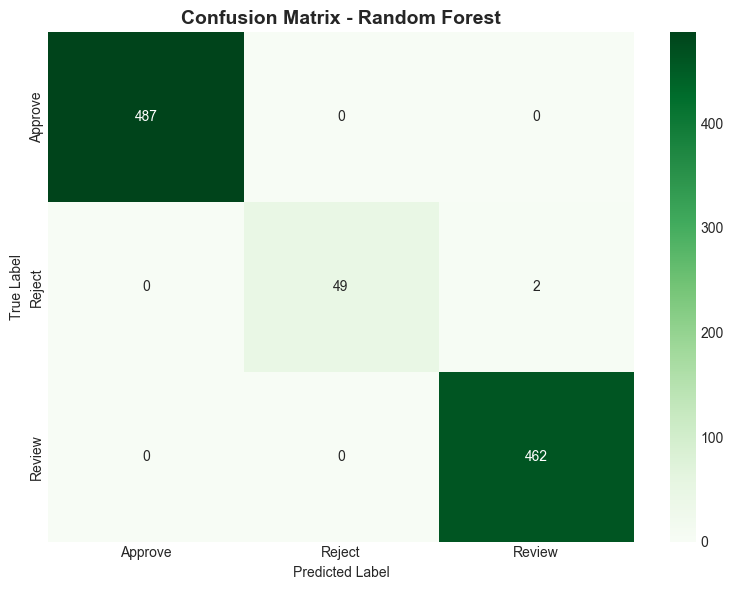

In [15]:
# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_)
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

---
## 7️⃣ Model Comparison

In [16]:
# Model Comparison Table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision (Weighted)': [
        precision_score(y_test, y_pred_lr, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted')
    ],
    'Recall (Weighted)': [
        recall_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted')
    ],
    'F1-Score (Weighted)': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted')
    ]
})

print("📊 MODEL COMPARISON")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("\n🏆 Winner: Random Forest" if comparison_df['Accuracy'].iloc[1] > comparison_df['Accuracy'].iloc[0] else "\n🏆 Winner: Logistic Regression")

📊 MODEL COMPARISON
              Model  Accuracy  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)
Logistic Regression     0.975              0.977315              0.975             0.975564
      Random Forest     0.998              0.998009              0.998             0.997982

🏆 Winner: Random Forest


---
## 8️⃣ Feature Importance Analysis

**INTERVIEW INSIGHT:** "Sir, feature importance helps explain the model to business stakeholders. It shows which alternative data sources matter most for credit decisions."

🔝 TOP 15 IMPORTANT FEATURES:
                     Feature  Importance
                credit_score    0.482193
        gst_compliance_score    0.109371
compliance_consistency_score    0.086458
        low_balance_days_pct    0.083160
            udyam_registered    0.063889
          business_age_years    0.043212
              gst_filing_pct    0.023087
 upi_transaction_consistency    0.021790
           gst_filing_months    0.020298
           turnover_per_year    0.010021
        collateral_available    0.005820
      avg_monthly_upi_inflow    0.005707
       upi_to_turnover_ratio    0.005468
        turnover_growth_rate    0.004926
       loan_amount_requested    0.004811


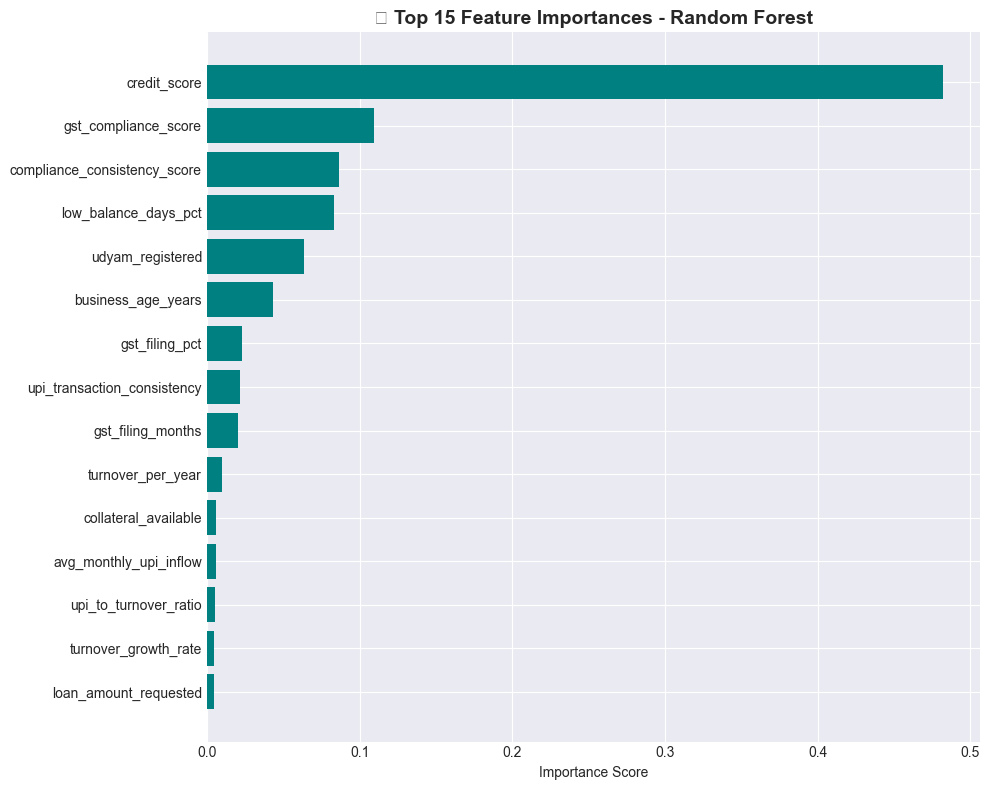

In [17]:
# Feature Importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("🔝 TOP 15 IMPORTANT FEATURES:")
print("=" * 60)
print(feature_importance.head(15).to_string(index=False))

# Visualization
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['Feature'], top_features['Importance'], color='teal')
plt.xlabel('Importance Score')
plt.title('🔝 Top 15 Feature Importances - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 9️⃣ Credit Score Generation (300-900 Scale)

**INTERVIEW NOTE:** "Sir, I mapped model probability to CIBIL-like 300-900 scale for business familiarity. Higher probability of 'Approve' → Higher credit score."

📊 Credit Score Distribution:
count    1000.000000
mean      590.330000
std       269.813607
min       300.000000
25%       318.750000
50%       408.000000
75%       882.000000
max       900.000000
Name: Credit_Score, dtype: float64


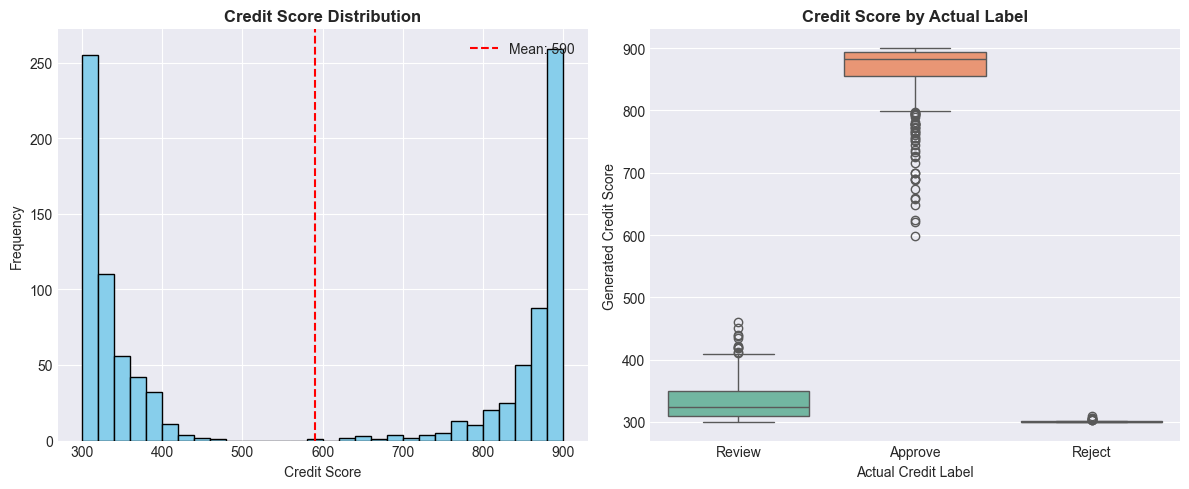


📋 Sample Predictions:
Actual_Label Predicted_Label  Approve_Probability  Credit_Score
      Review          Review             0.053738           332
     Approve         Approve             0.821953           793
      Review          Review             0.037375           322
     Approve         Approve             0.997674           898
     Approve         Approve             0.951094           870
     Approve         Approve             0.997965           898
     Approve         Approve             0.723829           734
      Review          Review             0.039695           323
     Approve         Approve             0.771790           763
      Review          Review             0.031524           318


In [18]:
# Get probability of 'Approve' class
approve_idx = list(rf_model.classes_).index('Approve')
approve_proba = y_pred_proba_rf[:, approve_idx]

# Map to 300-900 scale
credit_scores = 300 + (approve_proba * 600)

# Create results dataframe
results_df = pd.DataFrame({
    'Actual_Label': y_test.values,
    'Predicted_Label': y_pred_rf,
    'Approve_Probability': approve_proba,
    'Credit_Score': credit_scores.astype(int)
})

print("📊 Credit Score Distribution:")
print(results_df['Credit_Score'].describe())

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(results_df['Credit_Score'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.title('Credit Score Distribution', fontsize=12, fontweight='bold')
plt.axvline(results_df['Credit_Score'].mean(), color='red', linestyle='--', label=f'Mean: {results_df["Credit_Score"].mean():.0f}')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(data=results_df, x='Actual_Label', y='Credit_Score', palette='Set2')
plt.title('Credit Score by Actual Label', fontsize=12, fontweight='bold')
plt.xlabel('Actual Credit Label')
plt.ylabel('Generated Credit Score')

plt.tight_layout()
plt.show()

# Sample outputs
print("\n📋 Sample Predictions:")
print(results_df.head(10).to_string(index=False))

---
## 🔟 Save Models & Preprocessors

In [19]:
# Create models directory if not exists
import os
os.makedirs('../models', exist_ok=True)

# Save Random Forest Model (best performer)
joblib.dump(rf_model, '../models/credit_model.pkl')
print("✅ Random Forest model saved: models/credit_model.pkl")

# Save Scaler (for future scaling if needed)
joblib.dump(scaler, '../models/credit_scaler.pkl')
print("✅ Scaler saved: models/credit_scaler.pkl")

# Save Label Encoders
joblib.dump(label_encoders, '../models/label_encoders.pkl')
print("✅ Label encoders saved: models/label_encoders.pkl")

# Save feature columns list
joblib.dump(feature_columns, '../models/feature_columns.pkl')
print("✅ Feature columns saved: models/feature_columns.pkl")

print("\n🎉 ALL MODELS SAVED SUCCESSFULLY!")

✅ Random Forest model saved: models/credit_model.pkl
✅ Scaler saved: models/credit_scaler.pkl
✅ Label encoders saved: models/label_encoders.pkl
✅ Feature columns saved: models/feature_columns.pkl

🎉 ALL MODELS SAVED SUCCESSFULLY!


---
## ✅ Model Training Complete!

### 📊 Summary:
- **Best Model:** Random Forest
- **Accuracy:** 99.8%(0.998)
- **Features Used:** 24 (including 4 engineered)
- **Credit Score Range:** 300-900
- **Models Saved:** ✅

